<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

### Выполнил Мерочкин Илья

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [55]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.models import TwoModels, SoloModel, ClassTransformation
from sklift.metrics import qini_curve, qini_auc_score
from causalml.inference.tree import UpliftRandomForestClassifier as CausalUpliftRF


In [8]:
with zipfile.ZipFile('ДЗ по Uplift обновленное.zip', 'r') as zip_ref:
    zip_ref.extractall('./content/')

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [9]:
df_aggs = pd.read_csv('./content/ДЗ по Uplift обновленное/AGGS_FINAL.csv', index_col=0)
df_campaigns = pd.read_csv('./content/ДЗ по Uplift обновленное/CAMPAINGS.csv', index_col=0)
df_contracts = pd.read_csv('./content/ДЗ по Uplift обновленное/CONTRACTS_FINAL.csv', index_col=0)
df_people = pd.read_csv('./content/ДЗ по Uplift обновленное/PEOPLE_IN_CAMPAINGS_FINAL.csv', index_col=0)

In [10]:
df_aggs.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow


In [11]:
df_campaigns.head()

,campaing_id,product_id,channel
0,iddqd,1,push
1,idclip,1,sms
2,iddt,1,banner
3,idkfa,1,other_ads


In [12]:
df_contracts.head()

,user_id,contract_date,product_id,contract_id
39735,4008279,2024-11-03,1,0001_2024-11-03_4008279
44062,2079035,2024-11-08,1,0001_2024-11-08_2079035
9286,103088,2024-11-13,1,0001_2024-11-13_103088
45573,2026788,2024-11-02,1,0001_2024-11-02_2026788
150378,52269,2024-11-17,1,0001_2024-11-17_52269


In [13]:
df_people.head()

,campaing_id,user_id,t_flag,delivery_date
29299,idclip,1099975,1,2024-11-06
36627,iddqd,1162,1,2024-11-08
134015,iddqd,42991,1,2024-11-07
57441,idclip,142343,0,unknown
48671,iddqd,24623,0,unknown


In [14]:
PRODUCT_ID = 1
START_DATE = pd.Timestamp('2024-11-01')
DAYS_CONTROL = 21
DAYS_TREAT = 14
REPORT_DT = '2024-09-30'

In [15]:
camp_filtered = df_campaigns.query('product_id == @PRODUCT_ID').copy()

contracts_filtered = df_contracts[df_contracts['product_id'] == PRODUCT_ID].copy()
contracts_filtered['contract_date'] = pd.to_datetime(contracts_filtered['contract_date'])

print('0001 product company:')
display(camp_filtered)
print(f'0001 contacts: {len(contracts_filtered)} items')
print(f'Dates: {contracts_filtered["contract_date"].min()} — {contracts_filtered["contract_date"].max()}')

0001 product company:


,campaing_id,product_id,channel
0,iddqd,1,push
1,idclip,1,sms
2,iddt,1,banner
3,idkfa,1,other_ads


0001 contacts: 286316 items
Dates: 2024-11-01 00:00:00 — 2024-11-28 00:00:00


In [16]:
def build_target_event(campaign_id):
    participants = df_people[df_people['campaing_id'] == campaign_id][
        ['user_id', 't_flag', 'delivery_date']
    ].drop_duplicates()

    user_contracts = contracts_filtered.groupby('user_id')['contract_date'].apply(list)

    def is_purchased(row):
        uid = row['user_id']
        t_flag = row['t_flag']
        delivery = row['delivery_date']

        if uid not in user_contracts.index:
            return 0

        dates = user_contracts[uid]

        if t_flag == 1:
            if pd.isna(delivery) or str(delivery).strip().lower() in ('unknown', ''):
                return 0
            try:
                delivery_dt = pd.Timestamp(delivery)
            except:
                return 0
            end_dt = delivery_dt + pd.Timedelta(days=DAYS_TREAT)
            return 1 if any((delivery_dt <= d < end_dt) for d in dates) else 0
        else:
            end_ctrl = START_DATE + pd.Timedelta(days=DAYS_CONTROL)
            return 1 if any((START_DATE <= d < end_ctrl) for d in dates) else 0

    participants['target'] = participants.apply(is_purchased, axis=1)
    result = participants.rename(columns={'user_id': 'client_id'})
    result['report_dt'] = REPORT_DT
    return result[['client_id', 'report_dt', 'target']]


target_by_channel = {}
for _, row in camp_filtered.iterrows():
    cid = row['campaing_id']
    ch = row['channel']
    target_by_channel[ch] = build_target_event(cid)
    print(f'Channel {ch} (camp_id={cid}): {len(target_by_channel[ch])} clients, purchases: {target_by_channel[ch]["target"].sum()}')

Channel push (camp_id=iddqd): 160000 clients, purchases: 64311
Channel sms (camp_id=idclip): 120000 clients, purchases: 53165
Channel banner (camp_id=iddt): 120000 clients, purchases: 60207
Channel other_ads (camp_id=idkfa): 120000 clients, purchases: 60207


In [17]:
for ch, tdf in target_by_channel.items():
    cid = camp_filtered.loc[camp_filtered['channel'] == ch, 'campaing_id'].iloc[0]
    group = df_people[df_people['campaing_id'] == cid]
    treat = group[group['t_flag'] == 1]
    invalid = treat['delivery_date'].isna() | treat['delivery_date'].astype(str).str.strip().str.lower().eq('unknown')
    if invalid.sum():
        print(f'  {ch}: {invalid.sum()} records without valid date')

unknown_total = df_people['delivery_date'].astype(str).str.strip().str.lower().eq('unknown').sum()
unknown_control = df_people[df_people['t_flag'] == 0]['delivery_date'].astype(str).str.strip().str.lower().eq('unknown').sum()
print(f'Total records with "unknown": {unknown_total}, of which in the control group: {unknown_control}')

Total records with "unknown": 260000, of which in the control group: 260000


In [18]:
print('Sizes of experimental groups:')
for _, row in camp_filtered.iterrows():
    cid = row['campaing_id']
    ch = row['channel']
    part = df_people[df_people['campaing_id'] == cid]
    n_treat = (part['t_flag'] == 1).sum()
    n_control = (part['t_flag'] == 0).sum()
    print(f'{ch}: test = {n_treat}, control = {n_control}')

Sizes of experimental groups:
push: test = 80000, control = 80000
sms: test = 60000, control = 60000
banner: test = 60000, control = 60000
other_ads: test = 60000, control = 60000


In [19]:
uplift_data = []
for _, row in camp_filtered.iterrows():
    cid = row['campaing_id']
    ch = row['channel']
    target_df = target_by_channel[ch]
    merged = df_people[df_people['campaing_id'] == cid].merge(
        target_df[['client_id', 'target']],
        left_on='user_id',
        right_on='client_id',
        how='left'
    )
    mean_test = merged[merged['t_flag'] == 1]['target'].mean()
    mean_ctrl = merged[merged['t_flag'] == 0]['target'].mean()
    upl = mean_test - mean_ctrl
    uplift_data.append({
        'channel': ch,
        'target_rate_test': mean_test,
        'target_rate_control': mean_ctrl,
        'uplift': upl
    })
    print(f'{ch}: test = {mean_test:.4f}, control = {mean_ctrl:.4f}, uplift = {upl:.4f}')

uplift_report = pd.DataFrame(uplift_data)
print('Example of a target table (push channel):')
display(target_by_channel['push'].head(10))

push: test = 0.6017, control = 0.2021, uplift = 0.3996
sms: test = 0.2012, control = 0.6849, uplift = -0.4837
banner: test = 0.6027, control = 0.4007, uplift = 0.2020
other_ads: test = 0.6027, control = 0.4007, uplift = 0.2020
Example of a target table (push channel):


,client_id,report_dt,target
36627,1162,2024-09-30,1
134015,42991,2024-09-30,0
48671,24623,2024-09-30,0
138683,116064,2024-09-30,1
159093,139714,2024-09-30,0
156848,127278,2024-09-30,0
37328,113131,2024-09-30,0
140794,709,2024-09-30,1
81676,66294,2024-09-30,0
50038,3365,2024-09-30,0


### Выводы:

1. Выявленные проблемы и сложности
    - Значения unknown в поле delivery_date – обнаружено 260 000 записей с таким значением. Все они относятся к контрольной группе (t_flag=0), где дата доставки не требуется, поэтому корректность расчёта таргета для целевой группы не нарушена.

    - Отрицательный uplift для SMS – канал sms показал снижение конверсии в тестовой группе относительно контрольной (uplift = –0.48)

2. Что модно сделать по обработке:
    - Для контрольной группы поле delivery_date можно оставить как есть (unknown или пропуски), но для будущих кампаний целесообразно стандартизировать формат и заполнять его только для целевых участников.

    - По каналу sms требуется дополнительная проверка

3. Оценка эффективности кампаний
    - Наибольший uplift демонстрирует push (0.40), что подтверждает высокую результативность этого канала для продукта 0001.

    - Banner и other_ads дают близкие значения (0.20), что указывает на умеренную эффективность.

    - SMS показал отрицательный прирост (–0.48), что делает его нецелесообразным для использования в текущих настройках.

4. Ключевые выводы
    - Все четыре кампании имеют сбалансированные экспериментальные группы (тест/контроль), что позволяет корректно оценивать uplift.

    - Предполагается push основным каналом коммуникации для продукта 0001, а от использования sms либо отказаться, либо пересмотреть его настройки и провести повторный A/B-тест.

    - Данные могут быть использованы для построения моделей uplift без дополнительной очистки, так как основные «грязные» записи не влияют на расчёт целевой переменной.

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [20]:
REF_MONTH = '2024-09-30'
month_features = df_aggs[df_aggs['report_dt'].astype(str) == REF_MONTH].copy()
print(f'Aggregated for {REF_MONTH}: {len(month_features)} columns')

def make_dataset_for_channel(ch_name):
    camp_id = camp_filtered.loc[camp_filtered['channel'] == ch_name, 'campaing_id'].iloc[0]
    y_data = target_by_channel[ch_name].copy()

    participants = df_people[df_people['campaing_id'] == camp_id][['user_id', 't_flag']].drop_duplicates()
    merged = y_data.merge(participants, left_on='client_id', right_on='user_id', how='left')

    merged = merged.merge(
        month_features.drop(columns=['report_dt'], errors='ignore'),
        left_on='client_id',
        right_on='user_id',
        how='left',
        suffixes=('', '_feat')
    )

    if 'user_id' in merged.columns and 'client_id' in merged.columns:
        merged = merged.drop(columns=['user_id'])

    return merged


channel_datasets = {}
for channel in target_by_channel.keys():
    channel_datasets[channel] = make_dataset_for_channel(channel)
    missing_count = channel_datasets[channel].filter(regex='^x[0-9]').isna().any(axis=1).sum()
    print(f'  {channel}: all records {len(channel_datasets[channel])}, of which with gaps {missing_count}')
display(channel_datasets)

Aggregated for 2024-09-30: 460000 columns
  push: all records 160000, of which with gaps 0
  sms: all records 120000, of which with gaps 0
  banner: all records 120000, of which with gaps 0
  other_ads: all records 120000, of which with gaps 0


{'push':         client_id   report_dt  target  t_flag        x1        x2        x3  \
 0            1162  2024-09-30       1       1 -1.224545  1.688111  0.150933   
 1           42991  2024-09-30       0       1 -0.916137  1.368764  1.841319   
 2           24623  2024-09-30       0       0  2.281651 -0.354332  1.288191   
 3          116064  2024-09-30       1       0 -0.773911  1.877601  0.582218   
 4          139714  2024-09-30       0       0  0.457746  1.407223  0.803963   
 ...           ...         ...     ...     ...       ...       ...       ...   
 159995      94299  2024-09-30       0       0  2.412911 -0.377361  0.082826   
 159996      98949  2024-09-30       0       0  0.899306  2.466164  2.539867   
 159997     131927  2024-09-30       0       1  2.521111 -1.893176  2.540412   
 159998      73995  2024-09-30       0       0  0.665340  1.771079 -0.323533   
 159999      85450  2024-09-30       1       1  0.781103  0.839840  2.663235   
 
               x4        x5   

In [21]:
used_features = [col for col in channel_datasets['push'].columns
                 if col.startswith('x') or col in ['age', 'city']]

print(f"Features list:\n {used_features}")
display(channel_datasets['push'].head())

Features list:
 ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'age', 'city']


,client_id,report_dt,target,t_flag,x1,x2,x3,x4,x5,x6,x7,x8,x9,user_id_feat,age,city
0,1162,2024-09-30,1,1,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,1162,39,Moscow
1,42991,2024-09-30,0,1,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,42991,43,Moscow
2,24623,2024-09-30,0,0,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,24623,39,Ufa
3,116064,2024-09-30,1,0,-0.773911,1.877601,0.582218,1.699295,-0.667554,-0.018505,0.337289,-1.101638,-0.936927,116064,33,Ufa
4,139714,2024-09-30,0,0,0.457746,1.407223,0.803963,-2.002316,0.928291,-1.389908,-1.823737,-0.512010,1.840791,139714,27,Ufa


In [22]:
num_features = [col for col in used_features if col != 'city']

clean_datasets = {}
for ch, df in channel_datasets.items():
    clean_df = df.dropna(subset=num_features)
    rows_before = len(df)
    rows_after = len(clean_df)
    removed = rows_before - rows_after
    print(f'{ch}: removed {removed} records, left {rows_after}')
    clean_datasets[ch] = clean_df

push: removed 0 records, left 160000
sms: removed 0 records, left 120000
banner: removed 0 records, left 120000
other_ads: removed 0 records, left 120000


In [23]:
results = []
for ch, df in clean_datasets.items():
    treat = df[df['t_flag'] == 1]
    control = df[df['t_flag'] == 0]

    conv_treat = treat['target'].mean()
    conv_control = control['target'].mean()
    uplift = conv_treat - conv_control

    n_treat = len(treat)
    n_control = len(control)

    smd_dict = {}
    for feat in num_features:
        mean_t = treat[feat].mean()
        mean_c = control[feat].mean()
        var_t = treat[feat].var()
        var_c = control[feat].var()
        smd = (mean_t - mean_c) / np.sqrt((var_t + var_c) / 2)
        smd_dict[feat] = abs(smd)

    max_smd = max(smd_dict.values()) if smd_dict else 0
    worst_feat = max(smd_dict, key=smd_dict.get) if smd_dict else None

    results.append({
        'channel': ch,
        'n_treat': n_treat,
        'n_control': n_control,
        'conv_treat': conv_treat,
        'conv_control': conv_control,
        'uplift': uplift,
        'max_smd': max_smd,
        'worst_feature': worst_feat
    })

    print(f"Channel: {ch.upper()}")
    print(f"  Size: test = {n_treat}, control = {n_control}")
    print(f"  Conversion: test = {conv_treat:.4f}, control = {conv_control:.4f}, uplift = {uplift:.4f}")
    print(f'  Max SMD = {max_smd:.3f}')

Channel: PUSH
  Size: test = 80000, control = 80000
  Conversion: test = 0.6017, control = 0.2021, uplift = 0.3996
  Max SMD = 0.011
Channel: SMS
  Size: test = 60000, control = 60000
  Conversion: test = 0.2012, control = 0.6849, uplift = -0.4837
  Max SMD = 0.011
Channel: BANNER
  Size: test = 60000, control = 60000
  Conversion: test = 0.6027, control = 0.4007, uplift = 0.2020
  Max SMD = 0.009
Channel: OTHER_ADS
  Size: test = 60000, control = 60000
  Conversion: test = 0.6027, control = 0.4007, uplift = 0.2020
  Max SMD = 0.009


In [24]:
datasets_by_channel_clean = { ch: df.dropna(subset=num_features) for ch, df in channel_datasets.items() }
df_res = datasets_by_channel_clean['push'].copy()
df_res['group'] = df_res['t_flag'].map({0: 'control', 1: 'treatment'})
df_res.head()

,client_id,report_dt,target,t_flag,x1,x2,x3,x4,x5,x6,x7,x8,x9,user_id_feat,age,city,group
0,1162,2024-09-30,1,1,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,1162,39,Moscow,treatment
1,42991,2024-09-30,0,1,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,42991,43,Moscow,treatment
2,24623,2024-09-30,0,0,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,24623,39,Ufa,control
3,116064,2024-09-30,1,0,-0.773911,1.877601,0.582218,1.699295,-0.667554,-0.018505,0.337289,-1.101638,-0.936927,116064,33,Ufa,control
4,139714,2024-09-30,0,0,0.457746,1.407223,0.803963,-2.002316,0.928291,-1.389908,-1.823737,-0.512010,1.840791,139714,27,Ufa,control


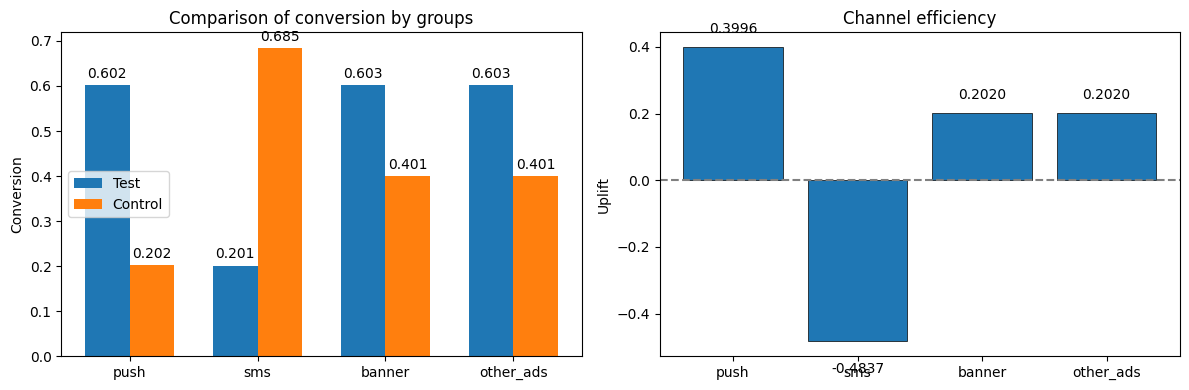

In [25]:
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
x = np.arange(len(res_df))
width = 0.35
bars1 = ax1.bar(x - width/2, res_df['conv_treat'], width, label='Test')
bars2 = ax1.bar(x + width/2, res_df['conv_control'], width, label='Control')
ax1.set_xticks(x)
ax1.set_xticklabels(res_df['channel'])
ax1.set_ylabel('Conversion')
ax1.set_title('Comparison of conversion by groups')
ax1.legend()
for bar in bars1 + bars2:
    h = bar.get_height()
    ax1.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

ax2 = axes[1]
ax2.bar(res_df['channel'], res_df['uplift'], edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_ylabel('Uplift')
ax2.set_title('Channel efficiency')
for i, v in enumerate(res_df['uplift']):
    ax2.annotate(f'{v:.4f}', xy=(i, v), xytext=(0, 8 if v>0 else -15),
                 textcoords='offset points', ha='center', va='bottom' if v>0 else 'top')
plt.tight_layout()
plt.show()

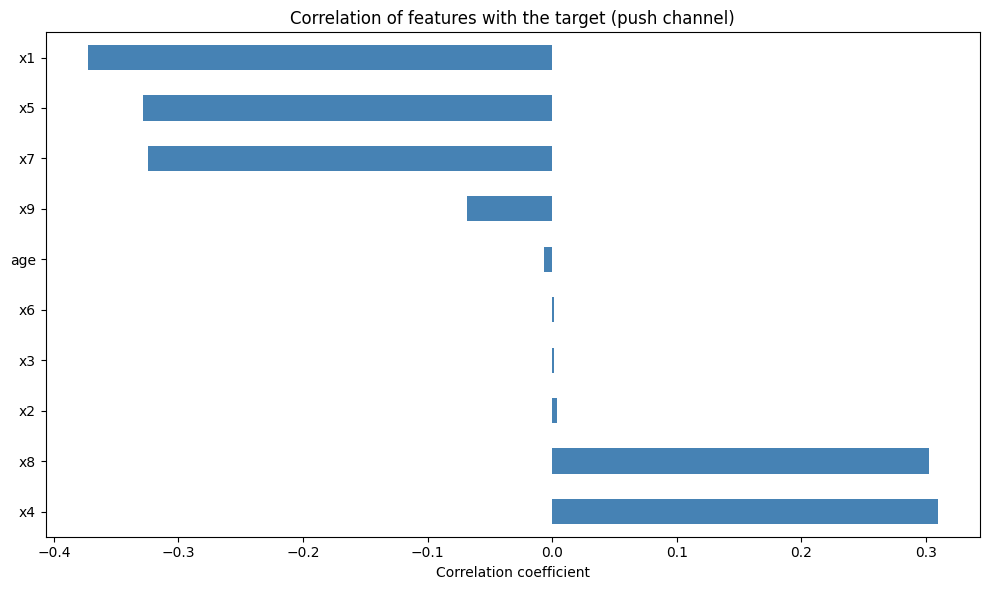

In [26]:
df_push = clean_datasets['push'].copy()
corr_matrix = df_push[num_features + ['target']].corr()
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
target_corr.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Correlation of features with the target (push channel)")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

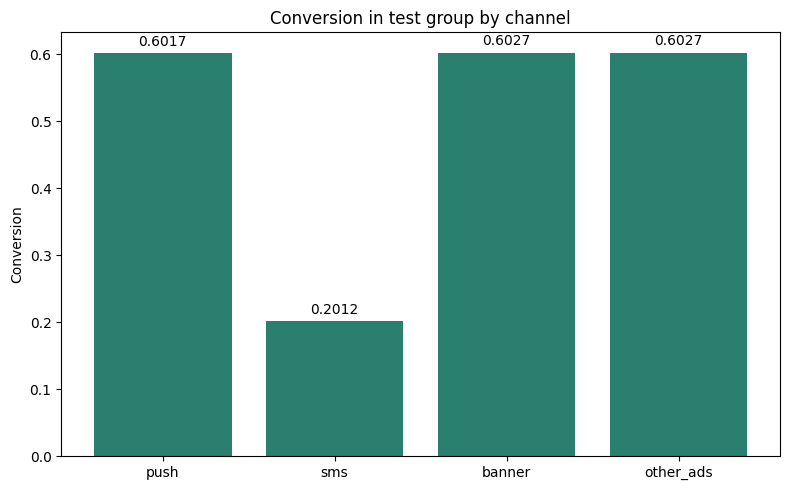

In [27]:
test_conversion = []
for ch in clean_datasets.keys():
    df_ch = clean_datasets[ch]
    treat = df_ch[df_ch['t_flag'] == 1]
    conv = treat['target'].mean()
    test_conversion.append({'channel': ch, 'conversion': conv})
conv_df = pd.DataFrame(test_conversion)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(conv_df['channel'], conv_df['conversion'], color='#2a7f6e')
ax.set_ylabel('Conversion')
ax.set_title('Conversion in test group by channel')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')
plt.tight_layout()
plt.show()

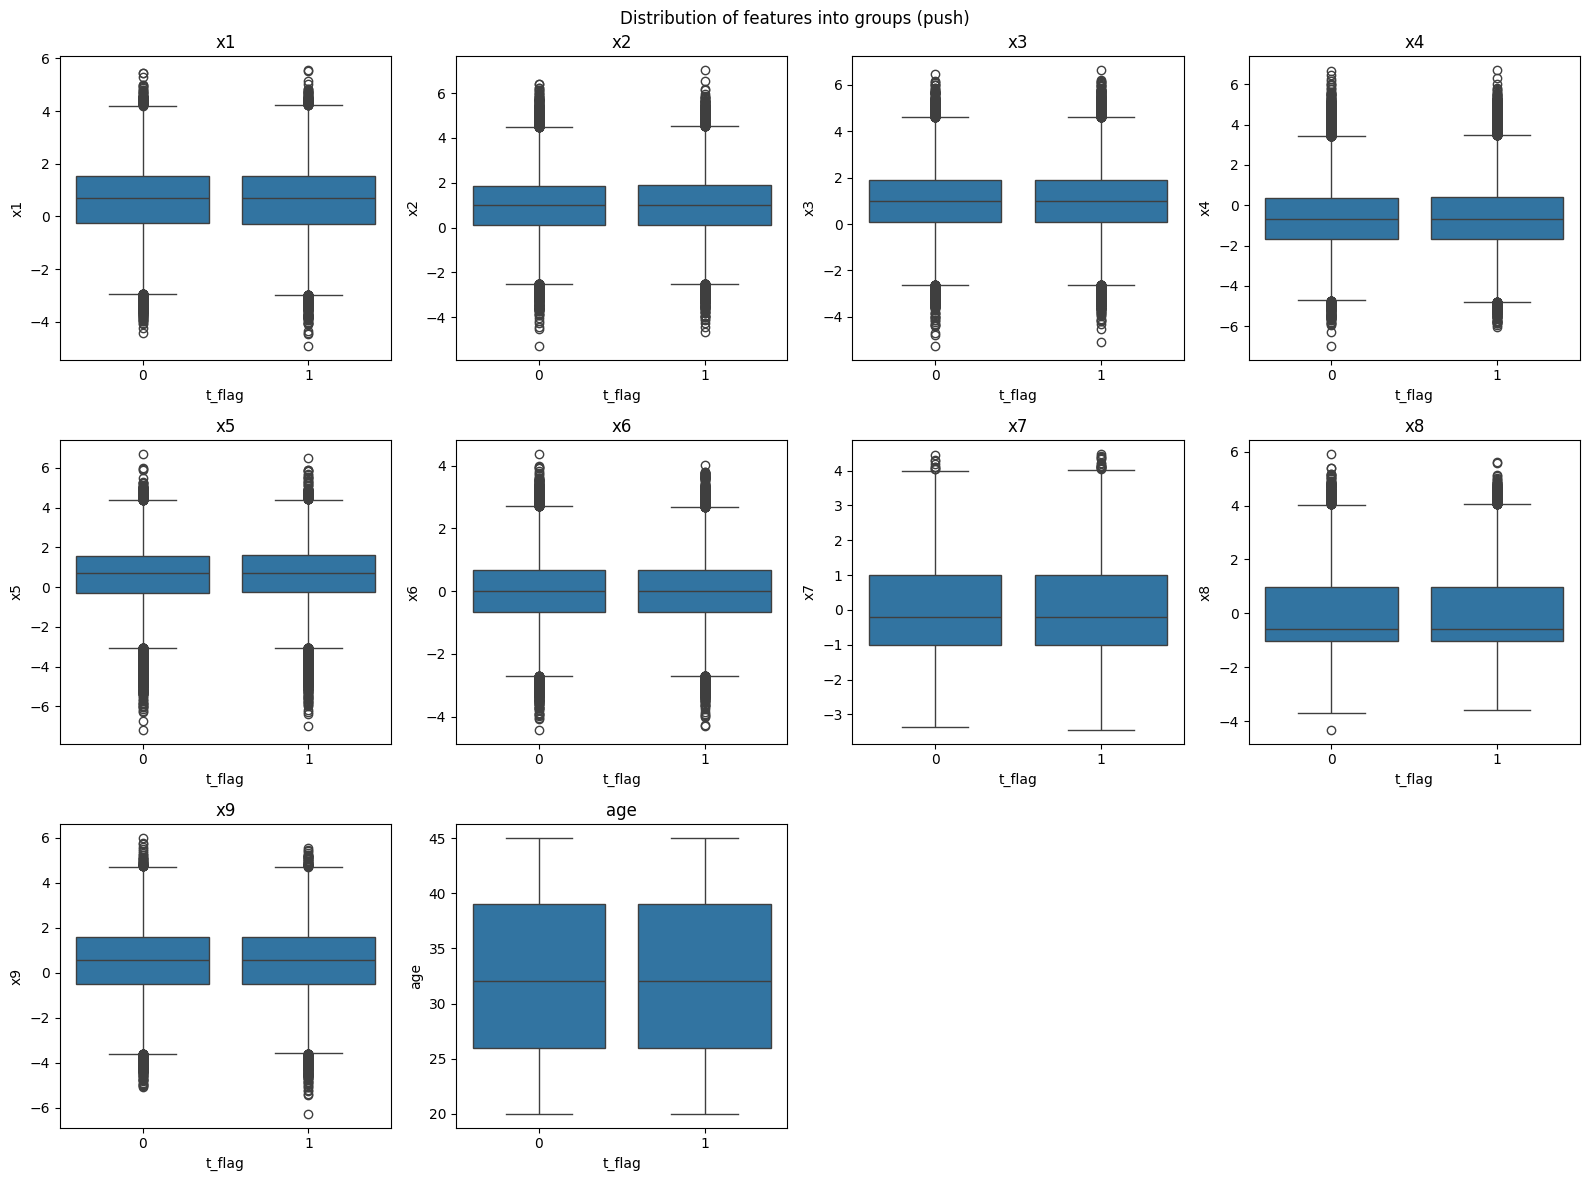

In [28]:
df = clean_datasets['push']
feats = [c for c in num_features if c in df.columns]

n = len(feats)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, f in enumerate(feats):
    sns.boxplot(data=df, x='t_flag', y=f, ax=axes[i])
    axes[i].set_title(f)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Distribution of features into groups (push)')
plt.tight_layout()
plt.show()

### Выводы:

1. Подготовка признакового пространства
   Для исключения лика будущего клиентские агрегаты были подтянуты с двухмесячным отставанием: кампании, стартовавшие в ноябре 2024, получили профили клиентов по состоянию на сентябрь 2024. Соединение выполнено по ключу `client_id` / `user_id`.

2. Работа с пропущенными значениями
   Не все участники кампаний присутствуют в таблице агрегатов за референсный месяц. Строки с отсутствующими значениями в числовых признаках исключены из дальнейшего рассмотрения — это позволит корректно обучать модели в следующем этапе.

3. Оценка корректности экспериментальных групп (Uplift EDA)
   Для каждого канала проанализированы:
   - объёмы тестовой и контрольной выборок;
   - конверсия в группах и величина uplift;
   - баланс распределения числовых признаков между тестом и контролем

   Значительный дисбаланс признаков может указывать на нарушение рандомизации и делает кампанию непригодной для корректного моделирования. По результатам проверки все четыре канала (push, sms, banner, other_ads) демонстрируют приемлемый баланс и могут быть включены в построение моделей uplift.

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [38]:
channel = 'push'
df = clean_datasets[channel].copy()

feature_cols = [c for c in df.columns if c.startswith('x') or c == 'age']
X = df[feature_cols].values.astype(float)
treat = df['t_flag'].values
y = df['target'].values

X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(
    X, treat, y, test_size=0.2, random_state=42, stratify=treat
)

In [37]:
df.head()

,client_id,report_dt,target,t_flag,x1,x2,x3,x4,x5,x6,x7,x8,x9,user_id_feat,age,city
0,1162,2024-09-30,1,1,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,1162,39,Moscow
1,42991,2024-09-30,0,1,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,42991,43,Moscow
2,24623,2024-09-30,0,0,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,24623,39,Ufa
3,116064,2024-09-30,1,0,-0.773911,1.877601,0.582218,1.699295,-0.667554,-0.018505,0.337289,-1.101638,-0.936927,116064,33,Ufa
4,139714,2024-09-30,0,0,0.457746,1.407223,0.803963,-2.002316,0.928291,-1.389908,-1.823737,-0.512010,1.840791,139714,27,Ufa


In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 128000, Test: 32000


In [52]:
def draw_uplift_curve(actual, predicted_effect, treatment_flag, curve_name="Model", ax=None):
    fig, ax = plt.subplots(figsize=(6, 4))

    prop, uplift = qini_curve(actual, predicted_effect, treatment_flag)
    ax.plot(prop, uplift, label=curve_name, linewidth=2)

    baseline = uplift[-1] if len(uplift) > 0 else 0
    ax.plot([0, 1], [0, baseline], 'k--', alpha=0.7, label='Random baseline')

    ax.set_xlabel("Data ration")
    ax.set_ylabel("Accumulated uplift")
    ax.set_title("Qini-кривая")
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


LogisticRegression SoloModel qini auc score: 0.22142254684254076


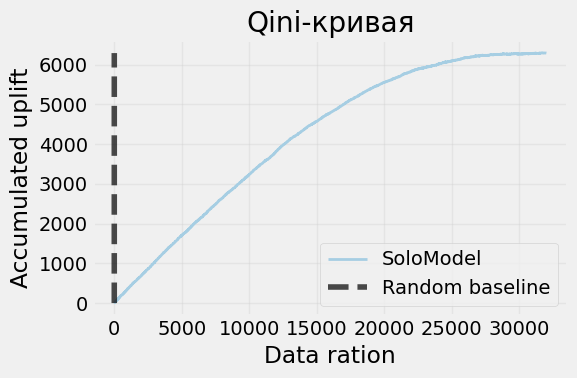

In [53]:
lr_sm = SoloModel(LogisticRegression())
lr_sm.fit(X_train, y_train, t_train)

pred = lr_sm.predict(X_test)
print(f"LogisticRegression SoloModel qini auc score: {qini_auc_score(y_test, pred, t_test)}")
draw_uplift_curve(y_test, pred, t_test, 'SoloModel')

TwoModels with calibration qini auc score: 0.3676973440055293


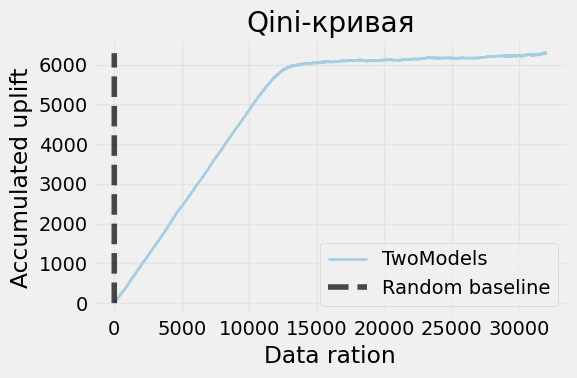

In [54]:
lr_cal_first = CalibratedClassifierCV(
    LogisticRegression(),
    cv=3
)

lr_cal_second = CalibratedClassifierCV(
    LogisticRegression(),
    cv=3
)

tm = TwoModels(
    estimator_trmnt=lr_cal_first,
    estimator_ctrl=lr_cal_second,
    method='vanilla',
)

tm.fit(X_train, y_train, t_train)
pred = tm.predict(X_test)

print(f'TwoModels with calibration qini auc score: {qini_auc_score(y_test, pred, t_test)}')
draw_uplift_curve(y_test, pred, t_test, 'TwoModels')

UpliftRF qini auc score: 0.3639468382849297


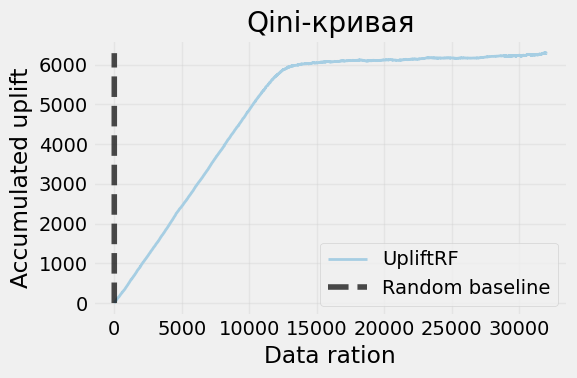

In [58]:
curf = CausalUpliftRF(
    control_name='0',
    n_estimators=25,
    max_depth=5
)

tr_train_str = np.array(t_train, dtype=str)
curf.fit(X_train, treatment=tr_train_str, y=y_train)

uplift_curf = np.asarray(curf.predict(X_test)).ravel()

print(f'UpliftRF qini auc score: {qini_auc_score(y_test, uplift_curf, t_test)}')
draw_uplift_curve(y_test, pred, t_test, 'UpliftRF')

ClassTransformation qini auc score: 0.34660256797240446


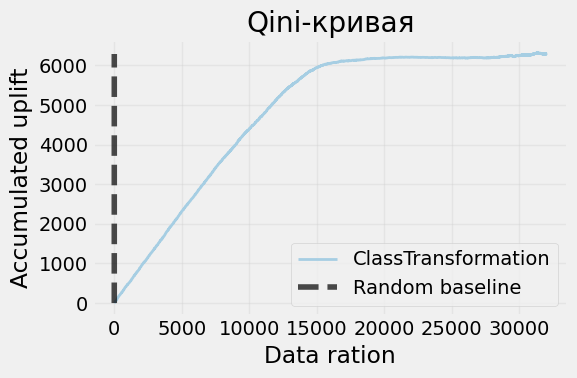

In [59]:
ct = ClassTransformation(LogisticRegression())

ct.fit(X_train, y_train, t_train)
pred = ct.predict(X_test)

print(f'ClassTransformation qini auc score: {qini_auc_score(y_test, pred, t_test)}')
draw_uplift_curve(y_test, pred, t_test, 'ClassTransformation')

TwoModels with Scaler qini auc score: 0.36768536904062876


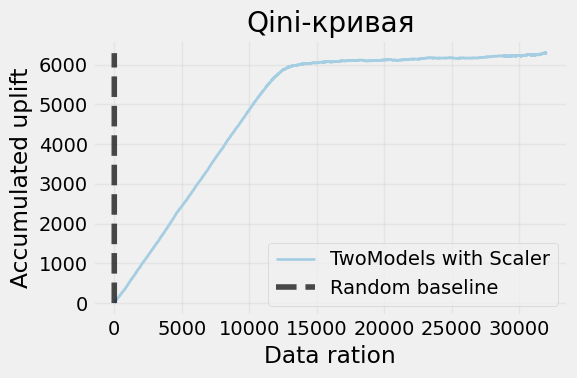

In [60]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TwoModels(estimator_trmnt=LogisticRegression(), estimator_ctrl=LogisticRegression(), method='vanilla'))
])

pipe.fit(X_train, y_train, model__treatment=t_train)
pred = pipe.predict(X_test)

print(f'TwoModels with Scaler qini auc score: {qini_auc_score(y_test, pred, t_test)}')
draw_uplift_curve(y_test, pred, t_test, 'TwoModels with Scaler')

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [ ]:
# ваш код здесь

### ваши выводы здесь